In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
from chemevo import oxygen

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 10,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]

# Numerical Solutions

First, let's do the numerical integrations for constant and exponential SFR.

In [36]:
t_array = np.linspace(0,14,int(1e4))
model = evo.Galaxy(t_array)
m_g_array_const = np.ones(len(t_array))
Z_oxygen_const = model.compute_z_O(m_g_array_const)
Z_Iron_const = model.compute_z_Fe(m_g_array_const)

tau_sfh = model.tau_sfh_arr[0]
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
Z_oxygen_exp = model.compute_z_O(m_g_array_exp)
M_O_exp = model.integrate_m_O(m_g_array_exp)
Z_Iron_exp = model.compute_z_Fe(m_g_array_exp)

In [37]:
Z_O_eq_const_sfr = model.analytic_eq_O("constant")
Z_O_const_sfr_ana = model.analytic_solutions_O("constant")

Z_O_eq_exp_sfr = model.analytic_eq_O("exponential")
Z_O_exp_sfr_ana = model.analytic_solutions_O("exponential")

In [38]:
Z_Fe_eq_const_sfr = model.analytic_eq_Fe("constant")
Z_Fe_const_sfr_ana = model.analytic_solutions_Fe("constant", 'sum')

Z_Fe_eq_exp_sfr = model.analytic_eq_Fe("exponential")
Z_Fe_exp_sfr_ana = model.analytic_solutions_Fe("exponential", 'sum')

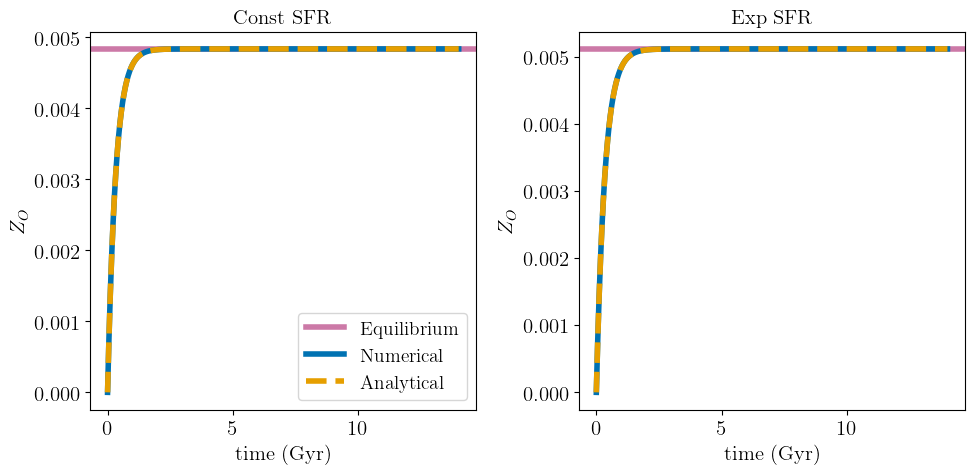

In [58]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.axhline(Z_O_eq_const_sfr, color = colors[4], label = 'Equilibrium', lw = 4)
plt.plot(t_array, Z_oxygen_const, color = colors[0], lw = 4, label = 'Numerical')
plt.plot(t_array, Z_O_const_sfr_ana, color = colors[1], alpha = 1, label = 'Analytical', lw = 4, linestyle = '--')

plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{O}$')
plt.title("Const SFR")
plt.legend(fontsize=14)
plt.tight_layout()



plt.subplot(1, 2, 2)
plt.axhline(Z_O_eq_exp_sfr, lw = 4, color = colors[4])
plt.plot(t_array, Z_oxygen_exp, color = colors[0], lw = 4)
plt.plot(t_array, Z_O_exp_sfr_ana, color = colors[1], lw = 4, linestyle = '--')


plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{O}$')
plt.title("Exp SFR")
plt.tight_layout()

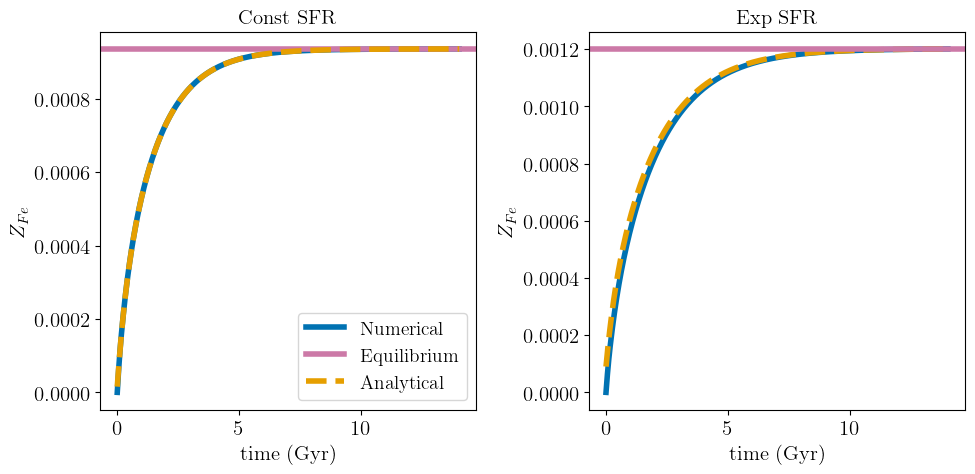

In [62]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.plot(t_array, Z_Iron_const, color = colors[0], alpha = 1, lw = 4, label = 'Numerical')
plt.axhline(Z_Fe_eq_const_sfr, color = colors[4], label = 'Equilibrium', lw = 4)
plt.plot(t_array, Z_Fe_const_sfr_ana, color = colors[1], alpha = 1, label = 'Analytical', lw = 4, linestyle = '--')

plt.legend(fontsize = 14)
plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')
plt.title("Const SFR")
plt.tight_layout()



plt.subplot(1, 2, 2)
plt.plot(t_array, Z_Iron_exp, color = colors[0], lw = 4)
plt.plot(t_array, Z_Fe_exp_sfr_ana, color = colors[1], lw = 4, linestyle = '--')
plt.axhline(Z_Fe_eq_exp_sfr[0], color = colors[4], lw = 4)


plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')
plt.title("Exp SFR")
plt.tight_layout()

# Everything in [X/Y] 

In [41]:
SolarO=0.0056		# solar oxygen abundance by mass
SolarFe=0.0012		# solar iron abundance by mass

def ratio_to_sun(star, sun):
    return np.log10(star/sun + 1e-10)

#for constant SFR
consts = pd.DataFrame(columns=['O_H', 'Fe_H', 'O_Fe'])

consts['O_H'] = ratio_to_sun(Z_oxygen_const, SolarO)
consts['Fe_H'] = ratio_to_sun(Z_Iron_const, SolarFe)
consts = consts[(consts['O_H'] > -10) & (consts['Fe_H'] > -10)]
consts['O_Fe'] = consts['O_H'] - consts['Fe_H']

#For exp SFRs
exps = pd.DataFrame(columns=['O_H', 'Fe_H', 'O_Fe'])
exps['O_H'] = ratio_to_sun(Z_oxygen_exp, SolarO)
exps['Fe_H'] = ratio_to_sun(Z_Iron_exp, SolarFe)
exps = exps[(exps['O_H'] > -10) & (exps['Fe_H'] > -10)]
exps['O_Fe'] = exps['O_H'] - exps['Fe_H']

Text(0, 0.5, '[O/Fe]')

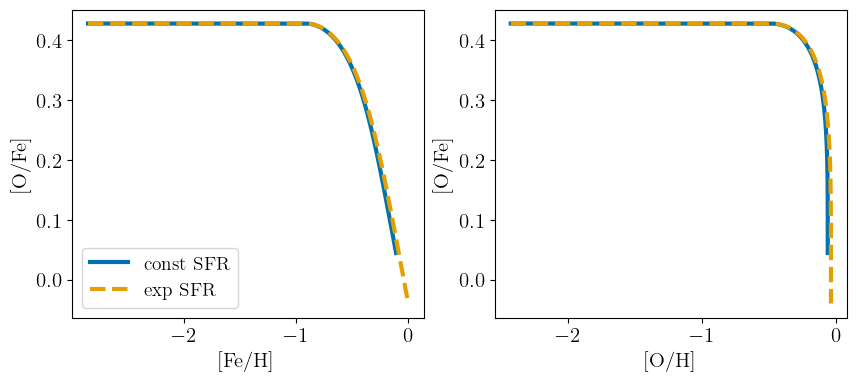

In [42]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(consts['Fe_H'], consts['O_Fe'], lw = 3, color = colors[0], label = 'const SFR')
plt.plot(exps['Fe_H'], exps['O_Fe'], lw = 3, linestyle = '--', color = colors[1], label = 'exp SFR')
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')
plt.legend(fontsize=14)

plt.subplot(1,2,2)
plt.plot(consts['O_H'], consts['O_Fe'], lw = 3, color = colors[0], label = 'const SFR')
plt.plot(exps['O_H'], exps['O_Fe'], lw = 3, linestyle = '--', color = colors[1], label = 'exp SFR')
plt.xlabel('[O/H]')
plt.ylabel('[O/Fe]')